In [99]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.integrate import quad
from astropy.cosmology import Planck18 as cosmo

In [100]:
h = 6.62 * 1.0e-34      # Planck constant in J/Hz
c = 299792458.      # light speed in m/s
keV2J = 1e3 * 1.6e-19     # conversion keV to joules
erg2J = 1e-7        # conversion erg to joules

In [178]:
# Function to generate a simulated population of GRBs with the specified parameters
def generate_grb_population(nb_grbs):
    """ Function to generate a population of GRBs
    """
    grb_population = []

    for i in range(nb_grbs):
        
        # generate randomly some parameters
        E = random.uniform(48, 54)    # in erg
        thetaCore = random.uniform(0.01, np.pi/2-0.01)   # in radians
        thetaWing = random.uniform(thetaCore+0.01, np.pi/2)   # in radians
        thetaObs = random.uniform(0., thetaWing)   # in radians
        n = 10 ** (-np.random.uniform(-1, 2))   # in cm-3
        z = random.uniform(0.01, 2.)
        dL = cosmo.luminosity_distance(z).value * 3.08e22   # in m
        T90 = random.uniform(0.01, 2.)  # T90 in seconds

        # calculate the Lorentz factor
        GammaCore = 10 ** random.uniform(1., 3.)
        Gamma = calculate_lorentz_factor(GammaCore, thetaObs, thetaCore)

        # Store the parameters of the simulated GRB
        grb = {'E0': 10 ** E,
               'thetaCore': thetaCore,
               'thetaWing': thetaWing,
               'thetaObs': thetaObs,
               'n': n,
               'z': z,
               'dL': dL,
               'Gamma': Gamma,
               'T90': T90
               }

        grb_population.append(grb)

    return grb_population


def calculate_flux(nu, grb, b=4, eta_gamma=0.1):
    """Function to calculate the spectral luminosity of the GRB at the viewing angle
    """
    
    ECore = grb['E0'] * erg2J
    thetaCore = grb['thetaCore']
    thetaWing = grb['thetaWing']
    thetaObs = grb['thetaObs']
    z = grb['z']
    dL = grb['dL']
    Gamma = grb['Gamma']
    T90 = grb['T90']
    
    
    Ep_comoving = 1. * keV2J    # energy of the peak in the rest-frame in eV
    nup_prime = Ep_comoving / h    # convert the energy of the peak in a frequency
    a = 0.3   # spectral index (typical)

    if thetaObs <= thetaWing:
        E = ECore * (1 + (1/b) * (thetaObs/thetaCore)**2)**(-b/2)   # power-law angular structure of the energy
    else:
        E = 0
    
    Eiso = E * eta_gamma   # conversion of the energy
    L = Eiso / T90
    Ep = Gamma * Ep_comoving
    
    nu_prime = nu / (1+z)
    
    # cut-off power law comoving spectral shape
    f = nu_prime**a * np.exp(-(1+a) * nu_prime / nup_prime)
    Lnu = (h * L / Ep) * f

    Fnu = (1+z) / (4*np.pi*dL**2) * Lnu
    
    # convert the flux in a flux of photons
    Fphot = Fnu / (h*nu)

    return Fphot


def calculate_lorentz_factor(GammaCore, thetaObs, thetaCore):
    """Function to calculate the Lorentz factor
    """
    
    Gamma = 1 + (GammaCore - 1) / (1 + (thetaObs/thetaCore)**3.5)

    return Gamma
    
    
def calculate_bat_flux(grb):
    """Calculate the flux of the GRB received by Swift BAT
    """
    
    T90 = grb['T90']
    
    nu_min = 15. * keV2J / h   # min frequency of BAT in Hz
    nu_max = 150. * keV2J / h   # max frequency of BAT in Hz
    Fbat, err = quad(calculate_flux, nu_min, nu_max, args=grb)

    return Fbat * 1e-4   # in photons/s/cm2


def consistency_with_catalog(grb):
    """Function to check the consistency of a GRB with the Swift BAT4 catalog based on flux comparison
    """
    
    grb_flux = calculate_bat_flux(grb)  # calculate the received flux for the simulated GRB
    catalog_flux = catalog['flux']  # get the catalog flux value
    
    # compare the simulated GRB flux with catalog flux
    if grb_flux < max(catalog_flux) and grb_flux > min(catalog_flux):
        return True
    else:
        return False

In [139]:
# SBAT4 catalog data
# list of GRBs from D'Avanzo et al. 2014
catalog = {'grb_name': ['050509B', '051210', '051221A', '060502B', '060801', '061217', '070714B', '070724A', 
                        '070729', '070829', '071227', '080123', '080905A', '090426', '090510', '090515', 
                        '100117A', '100625A', '100816A', '101219A', '111117A', '130603B'],
           'z': [0.2248, 1.3, 0.547, 0.287, 1.13, 0.83, 0.92, 0.457, 0.8, 0.473, 0.381, 0.495, 0.122, 2.609, 
                 0.903, 0.403, 0.92, 0.452, 0.805, 0.718, 1.3, 0.356],
           'T90': [0.02, 1.3, 1.4, 0.14, 0.5, 0.24, 80.0, 0.43, 0.99, 1.28, 144.98, 115.18, 1.02, 1.24, 0.3, 
                   0.04, 0.3, 0.33, 2.9, 0.6, 0.47, 0.18],     # in seconds
           'flux': [1.3, 1.0, 40.7, 3.4, 2.1, 2.0, 8.1, 1.5, 1.9, 1.9, 2.9, 6.1, 3.7, 4.7, 20.1, 5.2, 4.4, 9.3, 
                    12.9, 8.9, 5.8, 54.2]}    # in photons/cm2/s


# generate population of GRBs 
nb_grbs = 10000  # number of simulated GRBs

print('Generating GRBs...')
grb_population = generate_grb_population(nb_grbs)

print('Computing fluxes...')
Fbat = []
for grb in tqdm(grb_population):
    Fbat.append(calculate_bat_flux(grb))
print('Done!')

Generating GRBs...
Computing fluxes...


  0%|          | 0/10000 [00:00<?, ?it/s]

Done!


[0.02, 1.3, 1.4, 0.14, 0.5, 0.24, 0.43, 0.99, 1.28, 1.02, 1.24, 0.3, 0.04, 0.3, 0.33, 0.6, 0.47, 0.18]


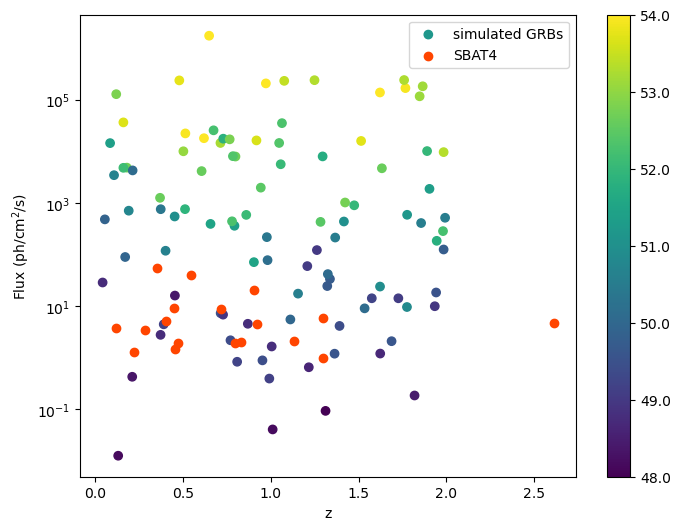

In [174]:
N = 100
indices = np.random.randint(0, len(grb_population), N)

E0_sample = [np.log10(grb_population[i]['E0']) for i in indices]
z_sample = [grb_population[i]['z'] for i in indices]
T90_sample = [grb_population[i]['T90'] for i in indices]
Fbat_sample = [Fbat[i] for i in indices]

z_cat = [catalog['z'][i] for i in range(len(catalog['z'])) if catalog['T90'][i] < 2]
T90_cat = [x for x in catalog['T90'] if x < 2]
flux_cat = [catalog['flux'][i] for i in range(len(catalog['flux'])) if catalog['T90'][i] < 2]


plt.figure(figsize=(8, 6))

plt.scatter(z_sample, Fbat_sample, label='simulated GRBs', c=E0_sample)   
plt.scatter(z_cat, flux_cat, label='SBAT4', color='orangered')
cbar = plt.colorbar()
cbar.set_ticks(np.linspace(0, 1, 7))
cbar.set_ticklabels(np.linspace(48, 54, 7))

plt.xlabel('z')
plt.ylabel('Flux (ph/cm$^2$/s)')
plt.yscale('log')
plt.legend()

In [118]:
# check consistency with SBAT4 catalog
consistent_grbs = [grb for grb in grb_population if consistency_with_catalog(grb)]

print(f"Number of consistent GRBs: {len(consistent_grbs)}")

Number of consistent GRBs: 2558


In [176]:
consistent_grbs

[{'E0': 1.0031647257246098e+50,
  'thetaCore': 1.2267446173086336,
  'thetaWing': 1.52553900822842,
  'thetaObs': 0.5822274631251538,
  'n': 0.025642218687159005,
  'z': 1.6018621427707147,
  'dL': 3.7373989304056904e+26,
  'Gamma': 56.12744628266165,
  'T90': 0.6987942037971486},
 {'E0': 7.333438466041624e+49,
  'thetaCore': 0.5861940817813869,
  'thetaWing': 1.3659822862462523,
  'thetaObs': 0.00010393633791646926,
  'n': 0.5750718546463955,
  'z': 0.7924715389666926,
  'dL': 1.571632256421967e+26,
  'Gamma': 56.54809962583959,
  'T90': 0.6051451772787202},
 {'E0': 2.2194423187283134e+50,
  'thetaCore': 0.03463298231915123,
  'thetaWing': 0.3342343433527834,
  'thetaObs': 0.32161701668201126,
  'n': 0.6299693781659261,
  'z': 0.8830913828802839,
  'dL': 1.79496683659987e+26,
  'Gamma': 1.2101488777715277,
  'T90': 1.926364432321897},
 {'E0': 4.201487062528381e+48,
  'thetaCore': 0.5691139652056072,
  'thetaWing': 1.4059298149234234,
  'thetaObs': 1.3946802204233346,
  'n': 0.03564527

In [179]:
nb_grbs = 1

grb_population = []
Fbat = []
consistent_grbs = []

while len(consistent_grbs) != 1e5:
    
    grb = generate_grb_population(nb_grbs)[0]
    
    grb_population.append(grb)
    Fbat.append(calculate_bat_flux(grb))
    
    if consistency_with_catalog(grb):
        consistent_grbs.append(grb)

In [180]:
len(consistent_grbs)

100000

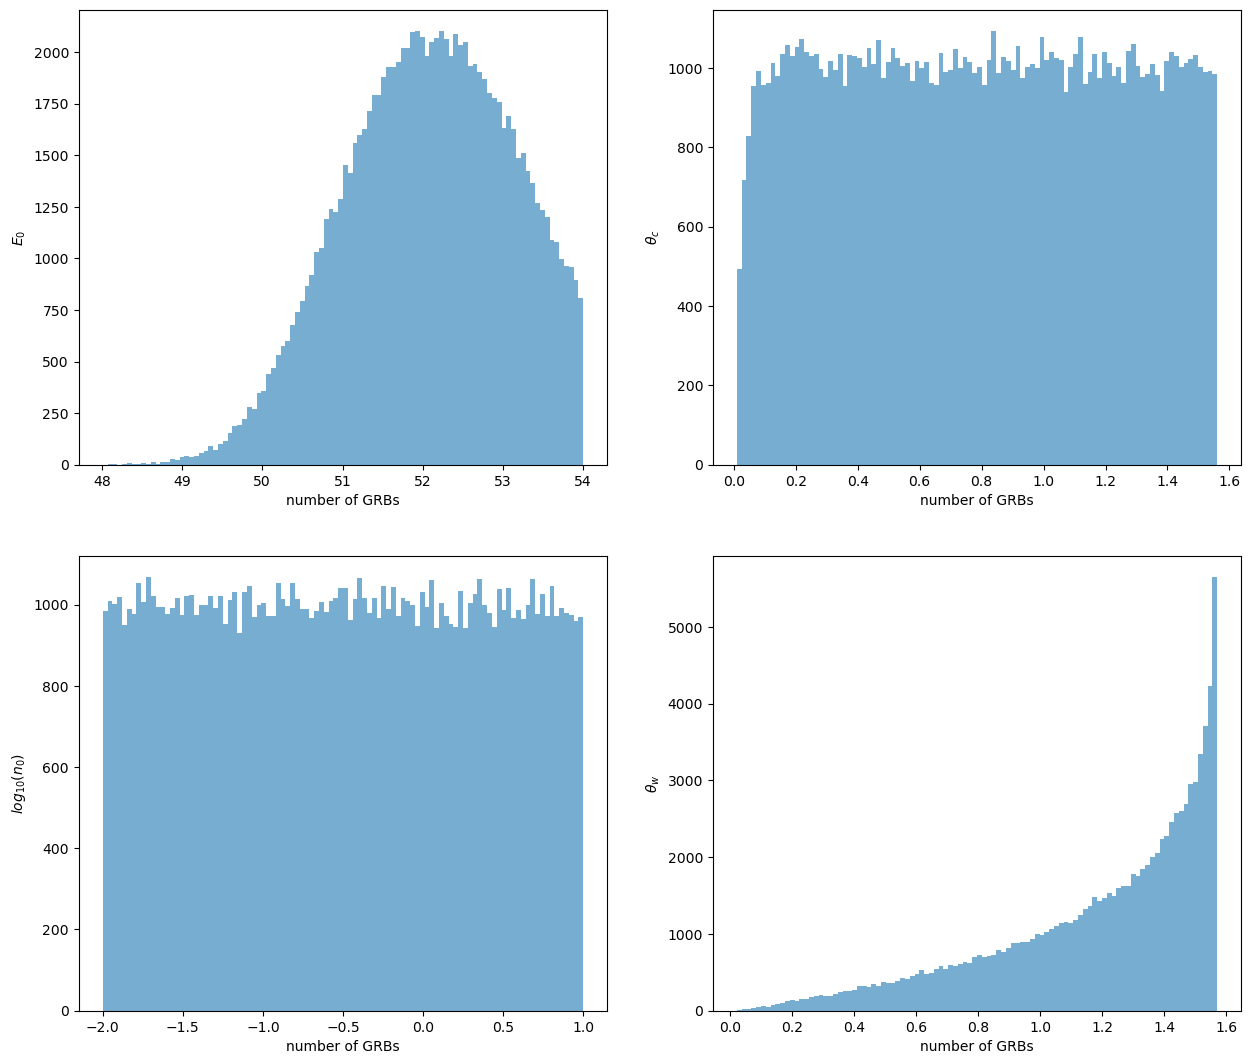

In [181]:
E0 = [grb['E0'] for grb in consistent_grbs]
thetaCore = [grb['thetaCore'] for grb in consistent_grbs]
n = [np.log10(grb['n']) for grb in consistent_grbs]
z = [grb['z'] for grb in consistent_grbs]
thetaWing = [grb['thetaWing'] for grb in consistent_grbs]

params = [np.log10(E0), thetaCore, n, thetaWing]
labels = ['$E_0$', r'$\theta_c$', r'$log_{10}(n_0)$', r'$\theta_w$']


fig, axes = plt.subplots(figsize=(15,13), nrows=3, ncols=2)

for i in range(4):
    
    ax = plt.subplot(2,2,i+1)
    ax.hist(params[i], bins=100, alpha=0.6);

    ax.set_xlabel('number of GRBs')
    ax.set_ylabel(labels[i])